# Extract Regional Colors

Extract one dominant color for each origami region in this order: head (excluding the beak), body, wing, and tail. Region masks come from the flat-net face definitions, and colors are clustered in perceptual CIELAB space.

In [1]:
import json
import os
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from sklearn.cluster import KMeans

from origami_texturing.paths import OUTPUT_DIR, RAW_DATA_DIR

texture_path = OUTPUT_DIR / "texture.png"
colors_path = OUTPUT_DIR / "colors.json"

pose_names = ["wingup", "wingdown"]
net_paths = {
    pose_name: RAW_DATA_DIR / f"dove-{pose_name}-net.json"
    for pose_name in pose_names
}
REGION_FACES = {
    "head": ["head"],  # beak is intentionally excluded
    "body": ["belly", "chest"],
    "wing": ["wing", "lower-wing", "upper-wing"],
    "tail": ["tail"],
}

N_CANDIDATES_PER_REGION = 3
ALPHA_THRESHOLD = 128
MAX_SAMPLES = 100_000
RANDOM_STATE = 42

## Load Texture and Build Region Masks

The face names in the wing-up and wing-down net JSON files define each anatomical region. The masks receive the same `y=x` symmetry used when composing the texture, and transparent or antialiased boundary pixels are excluded.

In [2]:
if not texture_path.exists():
    raise FileNotFoundError(
        f"Texture not found: {texture_path}. Run 03_map_texture.ipynb first."
    )

for path in net_paths.values():
    if not path.exists():
        raise FileNotFoundError(f"Net definition not found: {path}")

texture_image = Image.open(texture_path).convert("RGBA")
texture_rgba = np.asarray(texture_image, dtype=np.uint8)
texture_height, texture_width = texture_rgba.shape[:2]
foreground_mask = texture_rgba[..., 3] >= ALPHA_THRESHOLD


def load_json(path: Path) -> dict:
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def collect_points(data: dict) -> dict:
    points = {}
    for key in ("vertices", "features", "quaters", "quarters"):
        points.update(data.get(key, {}))
    return points


net_data = {pose_name: load_json(path) for pose_name, path in net_paths.items()}
region_masks = {}

for region_name, face_names in REGION_FACES.items():
    mask_image = Image.new("L", (texture_width, texture_height), 0)
    draw = ImageDraw.Draw(mask_image)
    found_faces = set()

    for data in net_data.values():
        points = collect_points(data)
        net_width, net_height = data["resolution"]
        scale_x = texture_width / net_width
        scale_y = texture_height / net_height

        for face_name in face_names:
            if face_name not in data["faces"]:
                continue
            polygon = [
                (points[name][0] * scale_x, points[name][1] * scale_y)
                for name in data["faces"][face_name]
            ]
            draw.polygon(polygon, fill=255)
            found_faces.add(face_name)

    if not found_faces:
        raise KeyError(f"No net faces found for region: {region_name}")

    region_mask = np.asarray(mask_image) > 0
    if texture_height != texture_width:
        raise ValueError("The y=x symmetric texture must be square")
    region_mask = (region_mask | region_mask.T) & foreground_mask
    if not region_mask.any():
        raise ValueError(f"Region has no foreground pixels: {region_name}")
    region_masks[region_name] = region_mask

print(f"Texture: {texture_path}")
print(f"Resolution: {texture_image.width} x {texture_image.height}")
for region_name, region_mask in region_masks.items():
    print(f"{region_name}: {region_mask.sum():,} pixels")

Texture: C:\Users\morph\GitHub\origami-texturing\outputs\texture.png
Resolution: 1024 x 1024
head: 23,606 pixels
body: 113,004 pixels
wing: 230,656 pixels
tail: 38,474 pixels


## Extract the Dominant Color per Region

Each region is split into a few candidate colors. The largest candidate cluster becomes that region's dominant color; this avoids the muddy color that can result from directly averaging gradients or texture details. At most `MAX_SAMPLES` pixels per region are fitted for speed.

In [3]:
def srgb_to_lab(rgb: np.ndarray) -> np.ndarray:
    """Convert uint8 or float sRGB values in [0, 255] to CIELAB (D65)."""
    srgb = np.asarray(rgb, dtype=np.float64) / 255.0
    linear = np.where(
        srgb <= 0.04045,
        srgb / 12.92,
        ((srgb + 0.055) / 1.055) ** 2.4,
    )

    rgb_to_xyz = np.array(
        [
            [0.4124564, 0.2126729, 0.0193339],
            [0.3575761, 0.7151522, 0.1191920],
            [0.1804375, 0.0721750, 0.9503041],
        ]
    )
    xyz = linear @ rgb_to_xyz
    xyz /= np.array([0.95047, 1.0, 1.08883])

    epsilon = 216 / 24389
    kappa = 24389 / 27
    f_xyz = np.where(xyz > epsilon, np.cbrt(xyz), (kappa * xyz + 16) / 116)

    return np.column_stack(
        (
            116 * f_xyz[:, 1] - 16,
            500 * (f_xyz[:, 0] - f_xyz[:, 1]),
            200 * (f_xyz[:, 1] - f_xyz[:, 2]),
        )
    )


def lab_to_srgb(lab: np.ndarray) -> np.ndarray:
    """Convert CIELAB (D65) values to clipped uint8 sRGB values."""
    lab = np.atleast_2d(np.asarray(lab, dtype=np.float64))
    fy = (lab[:, 0] + 16) / 116
    fx = fy + lab[:, 1] / 500
    fz = fy - lab[:, 2] / 200
    f_xyz = np.column_stack((fx, fy, fz))

    epsilon = 216 / 24389
    kappa = 24389 / 27
    xyz_scaled = np.where(
        f_xyz**3 > epsilon,
        f_xyz**3,
        (116 * f_xyz - 16) / kappa,
    )
    xyz = xyz_scaled * np.array([0.95047, 1.0, 1.08883])

    xyz_to_rgb = np.array(
        [
            [3.2404542, -0.9692660, 0.0556434],
            [-1.5371385, 1.8760108, -0.2040259],
            [-0.4985314, 0.0415560, 1.0572252],
        ]
    )
    linear = xyz @ xyz_to_rgb
    srgb = np.where(
        linear <= 0.0031308,
        12.92 * linear,
        1.055 * np.maximum(linear, 0) ** (1 / 2.4) - 0.055,
    )
    return np.round(np.clip(srgb, 0, 1) * 255).astype(np.uint8)


def rgb_to_hex(rgb: np.ndarray) -> str:
    return "#" + "".join(f"{int(channel):02X}" for channel in rgb)


def extract_dominant_color(
    rgb_pixels: np.ndarray,
    n_candidates: int = 3,
    max_samples: int = 100_000,
    random_state: int = 42,
) -> dict:
    if len(rgb_pixels) < n_candidates:
        raise ValueError("n_candidates cannot exceed the number of pixels")

    rng = np.random.default_rng(random_state)
    sample_size = min(max_samples, len(rgb_pixels))
    sample_indices = rng.choice(len(rgb_pixels), size=sample_size, replace=False)
    sample_lab = srgb_to_lab(rgb_pixels[sample_indices])

    model = KMeans(n_clusters=n_candidates, n_init=10, random_state=random_state)
    model.fit(sample_lab)

    all_labels = model.predict(srgb_to_lab(rgb_pixels))
    counts = np.bincount(all_labels, minlength=n_candidates)
    dominant_cluster = int(np.argmax(counts))
    rgb = lab_to_srgb(model.cluster_centers_[dominant_cluster])[0]

    return {
        "hex": rgb_to_hex(rgb),
        "rgb": [int(value) for value in rgb],
        "dominance": float(counts[dominant_cluster] / counts.sum()),
    }

In [4]:
colors = []

for region_name, region_mask in region_masks.items():
    region_rgb = texture_rgba[..., :3][region_mask]
    color = extract_dominant_color(
        region_rgb,
        n_candidates=N_CANDIDATES_PER_REGION,
        max_samples=MAX_SAMPLES,
        random_state=RANDOM_STATE,
    )
    color = {"region": region_name, **color}
    colors.append(color)
    print(
        f"{region_name}: {color['hex']}  "
        f"RGB{tuple(color['rgb'])}  dominance={color['dominance']:.1%}"
    )

head: #FABDA8  RGB(250, 189, 168)  dominance=60.3%
body: #75CF79  RGB(117, 207, 121)  dominance=56.6%
wing: #72CAE3  RGB(114, 202, 227)  dominance=37.2%
tail: #82C5EE  RGB(130, 197, 238)  dominance=53.5%


## Preview and Save Results

The regional preview fills each anatomical mask with its extracted dominant color. `colors.json` stores the four colors in head, body, wing, and tail order.

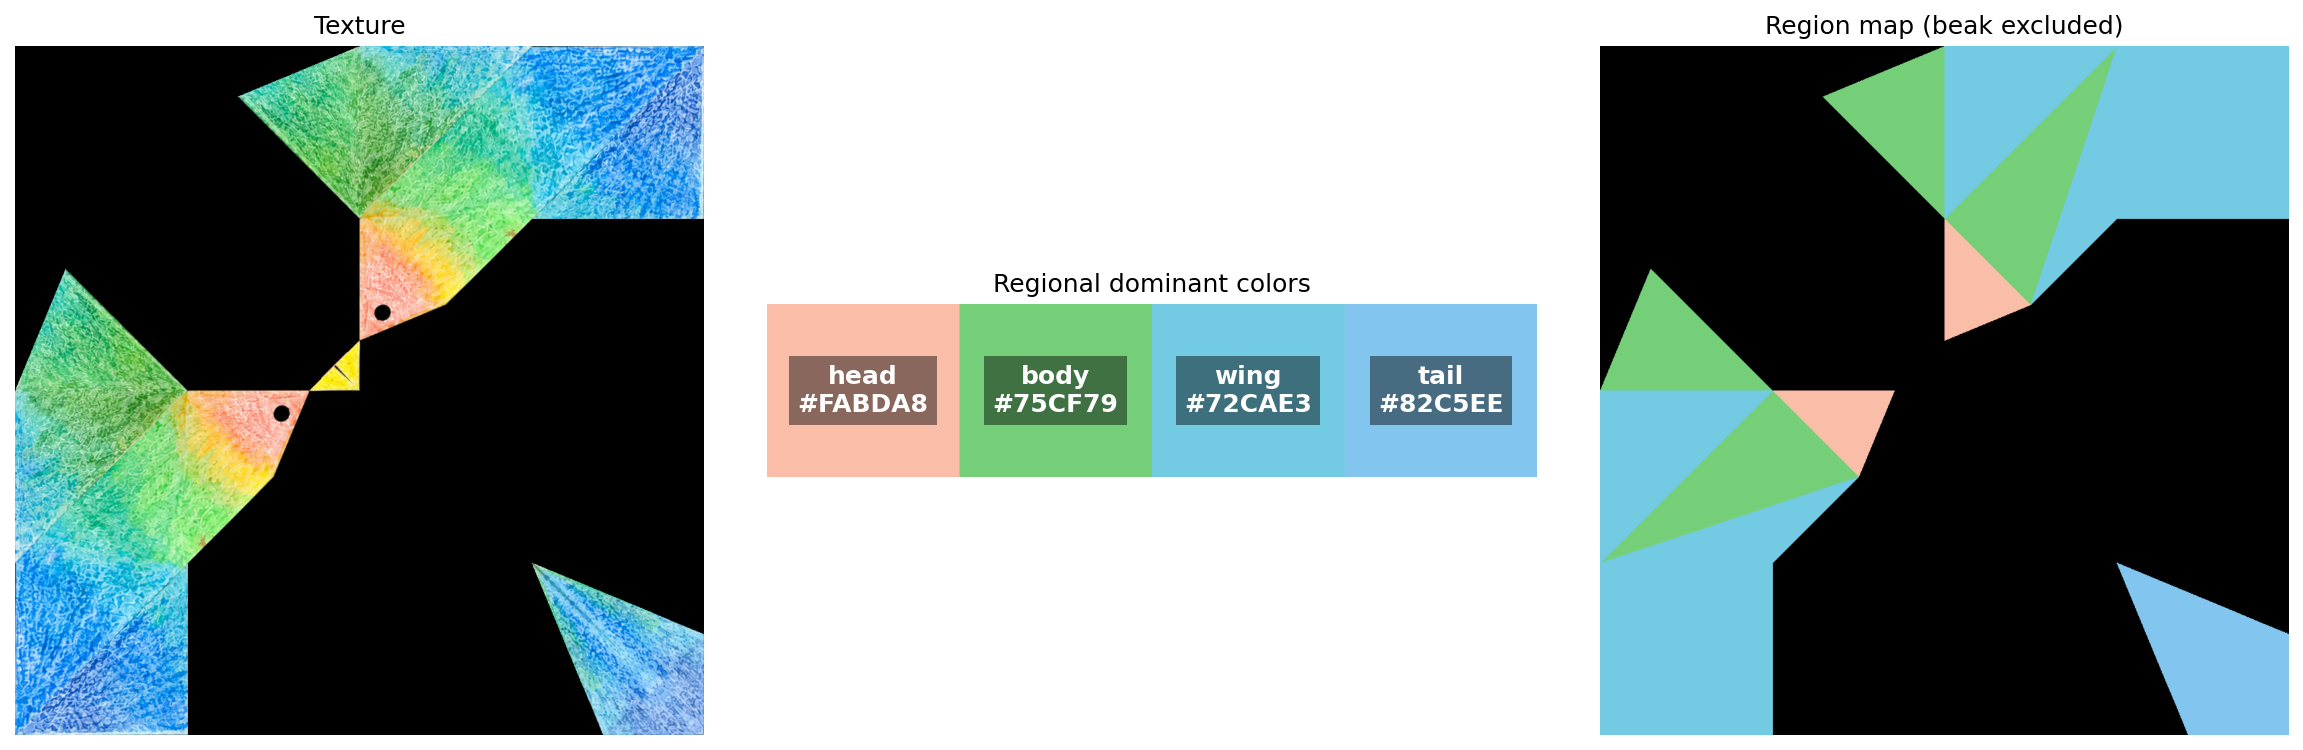

Saved color data to: C:\Users\morph\GitHub\origami-texturing\outputs\colors.json


In [5]:
regional_rgb = np.zeros_like(texture_rgba[..., :3])
for color in colors:
    regional_rgb[region_masks[color["region"]]] = color["rgb"]

palette_width = 800
palette_height = 180
palette_rgb = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)
segment_width = palette_width // len(colors)
for index, color in enumerate(colors):
    start = index * segment_width
    end = palette_width if index == len(colors) - 1 else (index + 1) * segment_width
    palette_rgb[:, start:end] = color["rgb"]

result = {
    "colors": [
        {key: color[key] for key in ("region", "hex", "rgb")}
        for color in colors
    ]
}
colors_path.write_text(json.dumps(result, indent=2), encoding="utf-8")

display_rgb = texture_rgba[..., :3].copy()
display_rgb[~foreground_mask] = 0
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=150)
axes[0].imshow(display_rgb)
axes[0].set_title("Texture")
axes[0].set_axis_off()

axes[1].imshow(palette_rgb)
axes[1].set_title("Regional dominant colors")
axes[1].set_axis_off()
for index, color in enumerate(colors):
    x = (index + 0.5) / len(colors)
    axes[1].text(
        x,
        0.5,
        f"{color['region']}\n{color['hex']}",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold",
        bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none"},
    )

axes[2].imshow(regional_rgb)
axes[2].set_title("Region map (beak excluded)")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

print(f"Saved color data to: {colors_path}")